# Importing required libraries for the project

In [1]:
from pyspark.sql.types import StringType, IntegerType, FloatType, TimestampType
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

# Creating spark session

In [2]:
spark = SparkSession.builder \
    .appName("DDA_final_project") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/01 14:52:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/01 14:52:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Defining all forms of nulls/missing values

In [3]:
def normalize_nulls(sdf):
    for col_name in sdf.columns:
        sdf = sdf.withColumn(
            col_name,
            F.when(
                F.trim(F.col(col_name).cast("string")).isin("", "nan", "NaN", "None", "none"),
                F.lit(None)
            ).otherwise(F.col(col_name))
        )
    return sdf

# Data set definition card

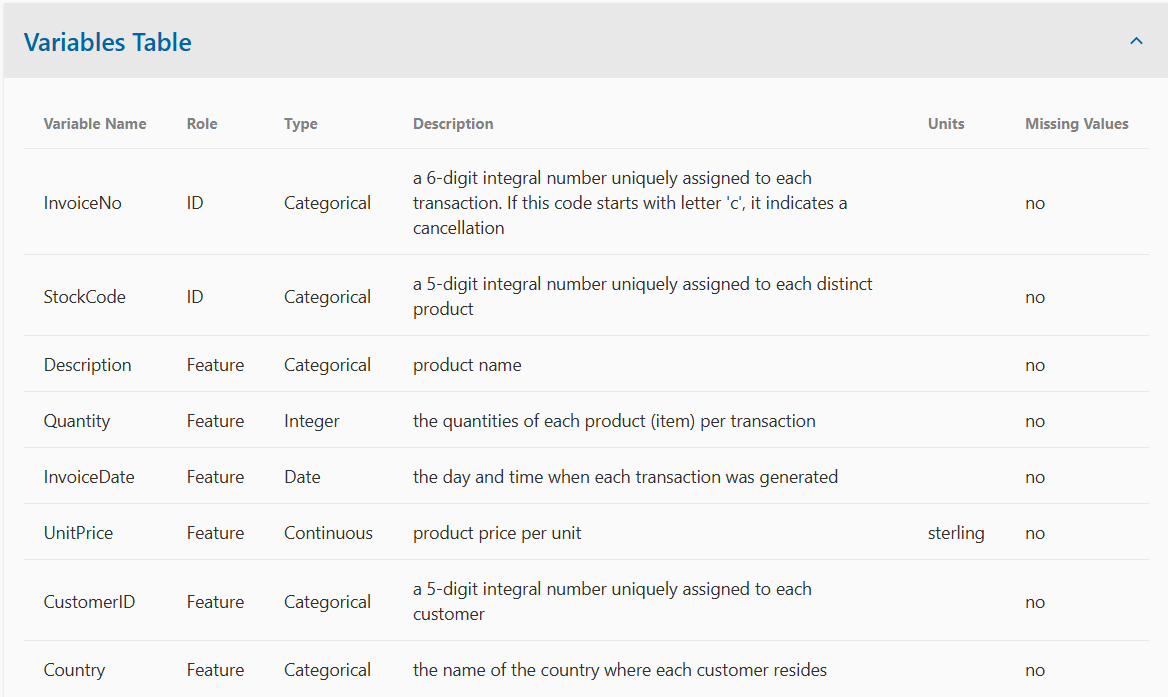

## Reading the data From HDFS

In [4]:
df1 = spark.read.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/bronze/sheet1/online_retail_sheet1.parquet")
df1  = normalize_nulls(df1)

In [5]:
df2 = spark.read.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/bronze/sheet2/online_retail_sheet2.parquet")
df2  = normalize_nulls(df2)

# Append/Union 2 pyspark data frames into single data frame called "df"

In [6]:
df = df1.union(df2)

# Viewing the first 10 rows of the combined data frame

In [7]:
df.show(10)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 503012|    21294|ETCHED GLASS COASTER|       2|2010-03-29 15:01:00| 2.51|       NULL|United Kingdom|
| 503012|    21330|WOODLAND ANIMAL  ...|       1|2010-03-29 15:01:00| 3.36|       NULL|United Kingdom|
| 503012|    21912|VINTAGE SNAKES & ...|       1|2010-03-29 15:01:00| 7.62|       NULL|United Kingdom|
| 503012|    21937|STRAWBERRY   PICN...|       1|2010-03-29 15:01:00| 5.91|       NULL|United Kingdom|
| 503012|    21955|DOOR MAT UNION JA...|       3|2010-03-29 15:01:00|13.57|       NULL|United Kingdom|
| 503012|    22099|CARAVAN SQUARE TI...|       1|2010-03-29 15:01:00| 2.51|       NULL|United Kingdom|
| 503012|    22196|SMALL HEART MEASU...|       1|2010-03-29 15:01:00| 1.6

# Viewing the last 10 rows of the combined data frame

In [8]:
df.orderBy(F.monotonically_increasing_id(), ascending=False).limit(10).show()

+-------+---------+--------------------+--------+-------------------+-----+-----------+-------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+-------+
| 581587|     POST|             POSTAGE|       1|2011-12-09 12:50:00| 18.0|    12680.0| France|
| 581587|    22138|BAKING SET 9 PIEC...|       3|2011-12-09 12:50:00| 4.95|    12680.0| France|
| 581587|    23255|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    23254|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    22899|CHILDREN'S APRON ...|       6|2011-12-09 12:50:00|  2.1|    12680.0| France|
| 581587|    22613|PACK OF 20 SPACEB...|      12|2011-12-09 12:50:00| 0.85|    12680.0| France|
| 581587|    23256|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    22629| SPACEBOY LUNCH BOX |

# Viewing the schema/structure of the combined data frame

In [9]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



# Viewing the number of missing values/nulls in each column in the combined data frame

In [10]:
null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|Customer ID|Country|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|      0|        0|       4382|       0|          0|    0|     243007|      0|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+



# Viewing the number of missing values/nulls in entire the combined data frame

In [11]:
total_nulls = null_counts.select(sum([F.col(c) for c in df.columns])).collect()[0][0]
print(f"Total Missing Values: {total_nulls}")

Total Missing Values: 247389


# Data cleaning and preprocessing

## (1) Cleaning "StockCode" column
### a) Keeping only the first 5 numbers of records/rows which start with numbers

### b) if the record doesn't start with a number then assign it as null

In [12]:
df = df.withColumn("StockCode",
    F.when(F.col("StockCode").rlike("^[0-9]"), F.regexp_extract(F.col("StockCode"), r"(\d{5})", 1))
    .otherwise(None)
)

### c) calculate the percentage of rows with null/missing value in this column to the total number of rows in the data set (or total number of rows in this column, as they are equal) then drop all of nulls/missing values in this column only (not entire data set)

In [13]:
total_count = df.count()
null_stock_count = df.filter(F.col("StockCode").isNull()).count()
print(f"StockCode Null Percentage: {(null_stock_count/total_count)*100:.2f}%")
df = df.dropna(subset=["StockCode"])

StockCode Null Percentage: 0.57%


## (2) Cleaning "Description" column

### a) Defining junk values to be removed from Description columns as they don't represent products names

In [14]:
junk_values = [
    "21494", "22719", "22467", "20713", "?", "??", "???", "????", "?missing",
    "?? missing", "???missing", "????missing", "? sold as sets?", "?sold as sets?",
    "?lost", "???lost", "????damages????", "?display?", "?sold individually?"
]

### b) assigning them as nulls/missing values in the Description column

In [15]:
df = df.withColumn("Description", F.when(F.col("Description").isin(junk_values), None).otherwise(F.col("Description")))

### c) Correcting miss-written product names
#### ex: "*Boombox Ipod Classic" => "Boombox Ipod Classic"

In [16]:
df = df.withColumn("Description", F.regexp_replace(F.col("Description"), r"^\*", ""))

### d) calculate the percentage of null rows in this column only to the total number of rows in the data set (or in the column as they are the same) then drop nulls in this column (not nulls in the entire data set)

In [17]:
null_desc_count = df.filter(F.col("Description").isNull()).count()
print(f"Description Null Percentage: {(null_desc_count/df.count())*100:.2f}%")
df = df.dropna(subset=["Description"])

Description Null Percentage: 0.42%


## (3) Cleaning "Quantity" column

### Converting Quantity negative values into positive values through taking absolute value to the negative Quantity value

In [18]:
df = df.withColumn("Quantity", F.abs(F.col("Quantity")))

## (4) Cleaning "Price" column

### a) Converting negative unit price rows values into positive values through taking absolute value to the negative unit price value

In [19]:
df = df.withColumn("Price", F.abs(F.col("Price")))

### b) replacing the rows of unit price value 0 with lowest positive value in the same "Price" column

In [20]:
min_positive_price = df.filter(F.col("Price") > 0).agg(F.min("Price")).collect()[0][0]
df = df.withColumn("Price", F.when(F.col("Price") == 0, min_positive_price).otherwise(F.col("Price")))

## (5) Cleaning "Customer ID" column

### a) Replacing each null/missing value in the "Customer ID" column with 0 value and storing result in a data frame called "df_all" to be used with analysis not related to customers

In [21]:
df_all = df.fillna({"Customer ID": 0})

### b) Dropping all records with nulls/missing values in column "Customer ID" and storing resul in a data frame called "df_customer_id" to be used with customer analysis

In [22]:
df_customer_id = df.dropna(subset=["Customer ID"])

## (6) Duplicated rows detection and dropping

### a) Viewing total number of duplicated records in data frame "df_all" and dropping them

In [23]:
dup_all = df_all.count() - df_all.dropDuplicates().count()
print(f"Duplicates in df_all: {dup_all}")
df_all = df_all.dropDuplicates()

Duplicates in df_all: 34290


### b) Viewing total number of duplicated records in data frame "df_customer_id" and dropping them

In [24]:
dup_cust = df_customer_id.count() - df_customer_id.dropDuplicates().count()
print(f"Duplicates in df_customer_id: {dup_cust}")
df_customer_id = df_customer_id.dropDuplicates()

Duplicates in df_customer_id: 26494


## (7) Adjusting data types of each column in each of the 2 pyspark data frames "df_all" and "df_customer_id"

In [25]:
def cast_columns(target_df):
    return target_df.withColumn("Invoice", F.col("Invoice").cast(StringType())) \
                    .withColumn("StockCode", F.col("StockCode").cast(IntegerType())) \
                    .withColumn("Description", F.col("Description").cast(StringType())) \
                    .withColumn("Quantity", F.col("Quantity").cast(IntegerType())) \
                    .withColumn("InvoiceDate", F.col("InvoiceDate").cast(TimestampType())) \
                    .withColumn("Price", F.col("Price").cast(FloatType())) \
                    .withColumn("Customer ID", F.col("Customer ID").cast(IntegerType())) \
                    .withColumn("Country", F.col("Country").cast(StringType()))

df_all = cast_columns(df_all)
df_customer_id = cast_columns(df_customer_id)

## Saving 2 cleaned/preprocessed data sets to the local disk

In [26]:
# df_all.toPandas().to_csv("df_all.csv", index=False)
# files.download("df_all.csv")
df_all.write.mode("overwrite").parquet("hdfs://localhost:9005/user/muhammed_mahmoud/silver/df_all.parquet")

In [27]:
# df_customer_id.toPandas().to_csv("df_customer_id.csv", index=False)
# files.download("df_customer_id.csv")
df_customer_id.write.mode("overwrite").parquet("hdfs://localhost:9005/user/muhammed_mahmoud/silver/df_customer_id.parquet")

# EDA (Exploratory Data Analysis)

## (1) Percentage of completed invoices vs Percentage of Cancelled invoices

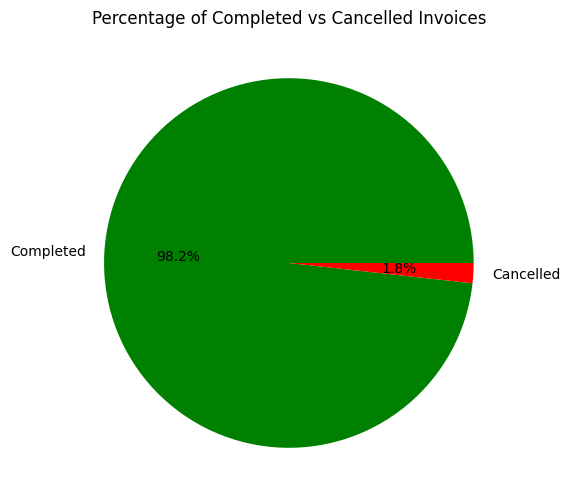

In [28]:
status_df = df_all.withColumn("Status", F.when(F.col("Invoice").startswith("C"), "Cancelled").otherwise("Completed"))
status_counts = status_df.groupBy("Status").count().toPandas()
plt.figure(figsize=(8, 6))
plt.pie(status_counts['count'], labels=status_counts['Status'], autopct='%1.1f%%',
        colors=['red' if x == 'Cancelled' else 'green' for x in status_counts['Status']])
plt.title("Percentage of Completed vs Cancelled Invoices")
plt.show()

In [29]:
description_map = df_all.select("StockCode", "Description").distinct() \
                        .groupBy("StockCode").agg(F.first("Description").alias("ProductDescription"))

## Function to add value of y-axis of point to the visual

In [30]:
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}' if p.get_height() > 100 else f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9)

## (2) Top 10 most sold products according to quantity

/tmp/ipykernel_18598/601943650.py:8: FutureWarning:                             

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=top_sold_with_desc, x="StockCode", y="TotalQuantity", palette="viridis")


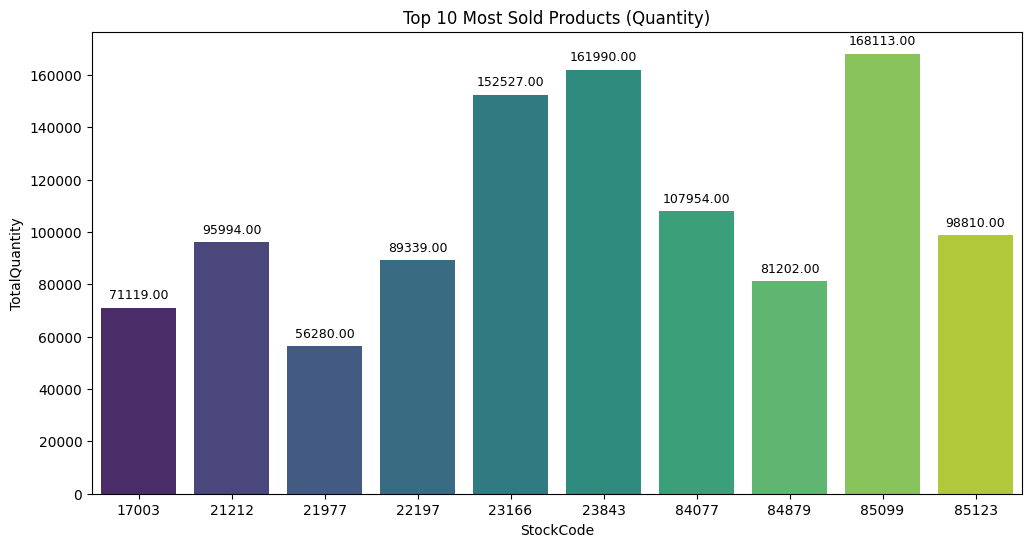

In [31]:
top_sold_data = df_all.groupBy("StockCode").agg(F.sum("Quantity").alias("TotalQuantity")) \
                      .orderBy(F.desc("TotalQuantity")).limit(10)

# Join with description map for the table
top_sold_with_desc = top_sold_data.join(description_map, "StockCode").toPandas()

plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=top_sold_with_desc, x="StockCode", y="TotalQuantity", palette="viridis")
add_labels(ax1)
plt.title("Top 10 Most Sold Products (Quantity)")
plt.show()

## (3) Top 10 most popular products according to presence in different invoices

/tmp/ipykernel_18598/1740199748.py:9: FutureWarning:                            

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=popular_with_desc, x="StockCode", y="InvoiceCount", palette="magma")


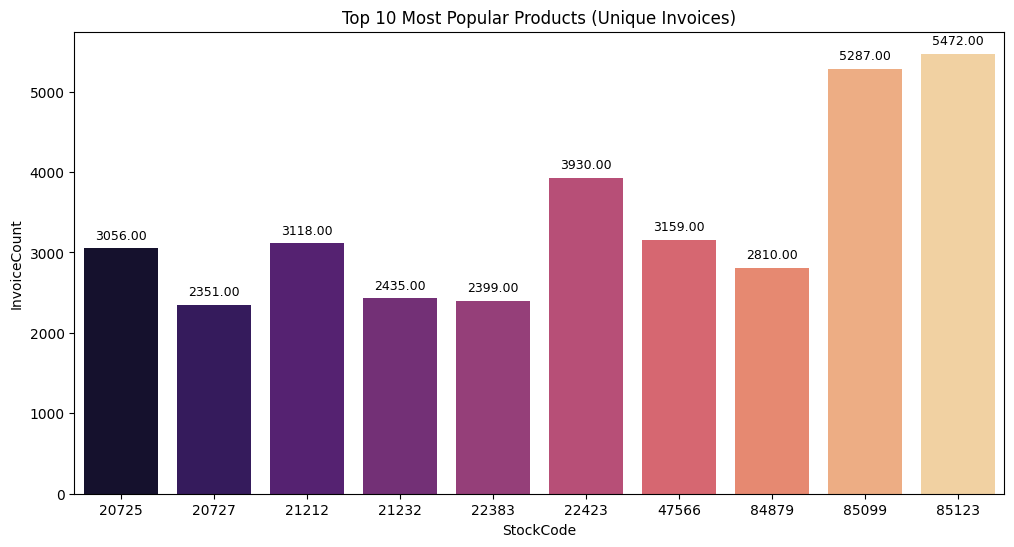

In [32]:
popular_data = df_all.filter(~F.col("Invoice").startswith("C")) \
                     .groupBy("StockCode").agg(F.countDistinct("Invoice").alias("InvoiceCount")) \
                     .orderBy(F.desc("InvoiceCount")).limit(10)

# Join with description map for the table
popular_with_desc = popular_data.join(description_map, "StockCode").toPandas()

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=popular_with_desc, x="StockCode", y="InvoiceCount", palette="magma")
add_labels(ax2)
plt.title("Top 10 Most Popular Products (Unique Invoices)")
plt.show()

## (4) Top 10 products according to sales

/tmp/ipykernel_18598/1855905766.py:19: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_with_desc, x=top_10_with_desc["StockCode"].astype(str),


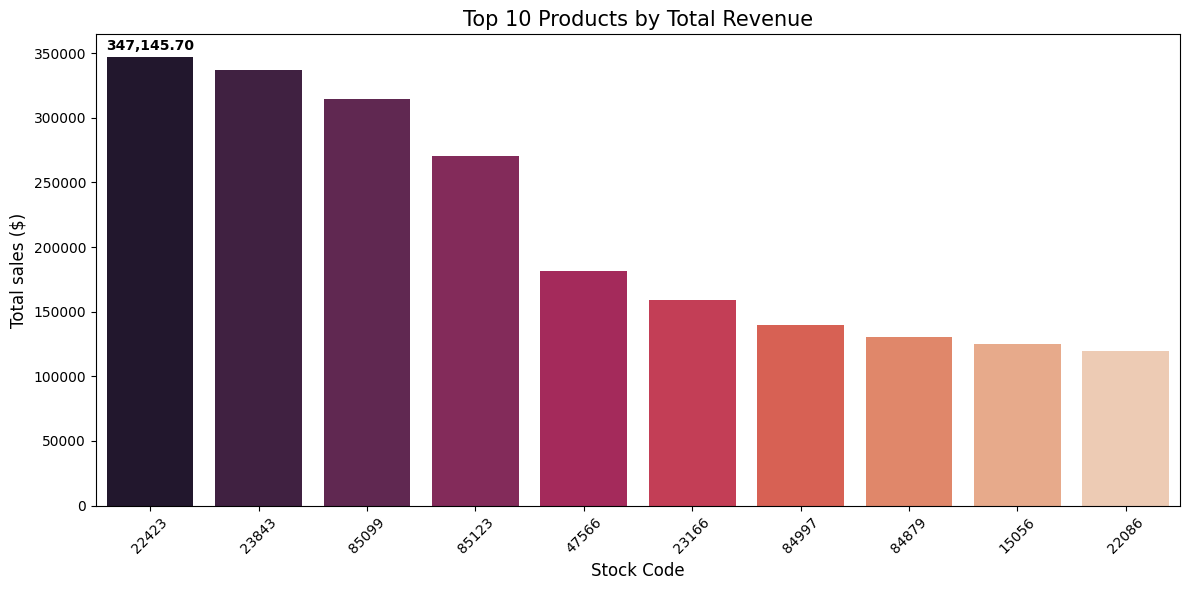

In [33]:
# 1. Calculate Revenue (Quantity * Price)
df_all = df_all.withColumn("Revenue", F.col("Quantity") * F.col("Price"))

# 2. Group by StockCode and sum Revenue to get top 10
top_10_revenue_spark = df_all.groupBy("StockCode") \
                             .agg(F.sum("Revenue").alias("TotalRevenue")) \
                             .orderBy(F.desc("TotalRevenue")) \
                             .limit(10)

# 3. Create a Description Lookup Table for these top 10
# (We drop duplicates to get one clean description per StockCode)
desc_lookup = df_all.select("StockCode", "Description").dropDuplicates(["StockCode"])
top_10_with_desc = top_10_revenue_spark.join(desc_lookup, on="StockCode", how="left") \
                                       .orderBy(F.desc("TotalRevenue")) \
                                       .toPandas()

# --- Visual 1: Bar Chart ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_with_desc, x=top_10_with_desc["StockCode"].astype(str),
                 y="TotalRevenue", palette="rocket")

# Add the exact revenue values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.2f}', padding=3, fontsize=10, fontweight='bold')

plt.title("Top 10 Products by Total Revenue", fontsize=15)
plt.xlabel("Stock Code", fontsize=12)
plt.ylabel("Total sales ($)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
print(top_10_with_desc[["StockCode", "Description", "TotalRevenue"]].to_string(index=False))

 StockCode                        Description  TotalRevenue
     22423           REGENCY CAKESTAND 3 TIER 347145.695833
     23843        PAPER CRAFT , LITTLE BIRDIE 336939.187641
     85099        JUMBO BAG RED WHITE SPOTTY  314120.127810
     85123 WHITE HANGING HEART T-LIGHT HOLDER 270575.458485
     47566                      PARTY BUNTING 181752.629766
     23166     MEDIUM CERAMIC TOP STORAGE JAR 159180.554261
     84997  RED 3 PIECE MINI DOTS CUTLERY SET 139372.131432
     84879      ASSORTED COLOUR BIRD ORNAMENT 130116.834133
     15056          EDWARDIAN PARASOL NATURAL 124700.326524
     22086    PAPER CHAIN KIT 50'S CHRISTMAS  119221.988976


## (5) Total orders placed by top 10 countries in the data set

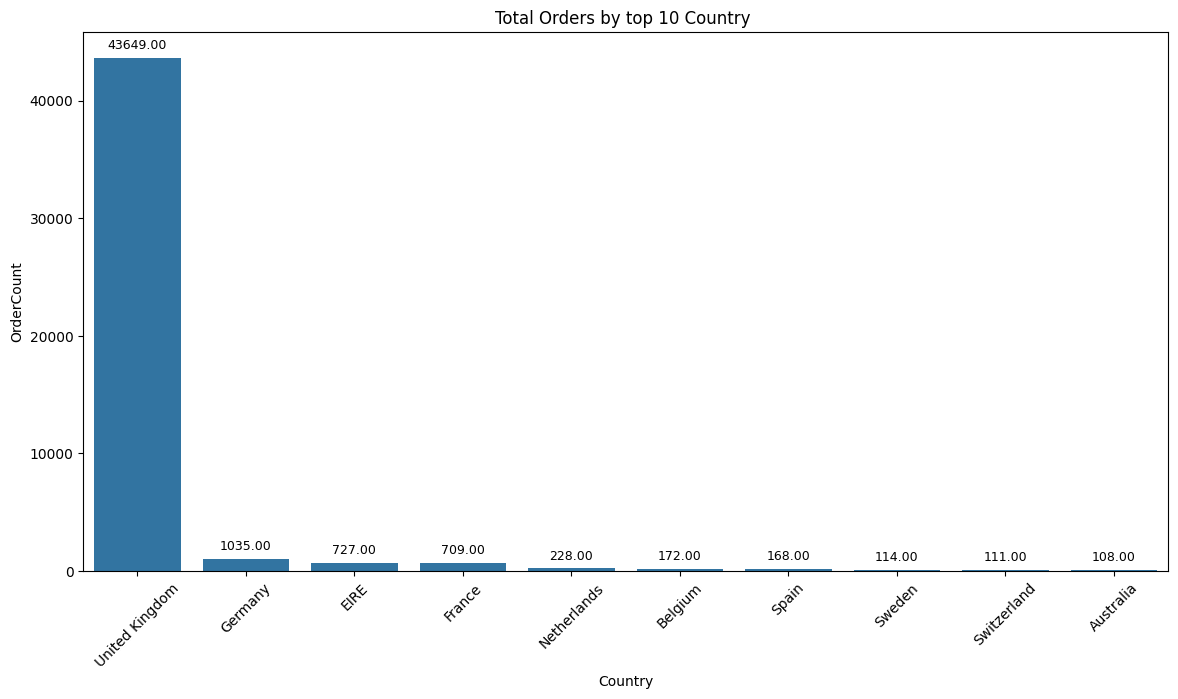

In [35]:
country_orders = df_all.groupBy("Country").agg(F.countDistinct("Invoice").alias("OrderCount")) \
                       .orderBy(F.desc("OrderCount")).limit(10).toPandas()

plt.figure(figsize=(14, 7))
ax3 = sns.barplot(data=country_orders, x="Country", y="OrderCount")
add_labels(ax3)
plt.title("Total Orders by top 10 Country ")
plt.xticks(rotation=45)
plt.show()

## (6) Total sales from top 10 countries in the data set

/tmp/ipykernel_18598/1819058271.py:13: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=country_revenue.head(20), x="Country", y="TotalRevenue", palette="viridis")


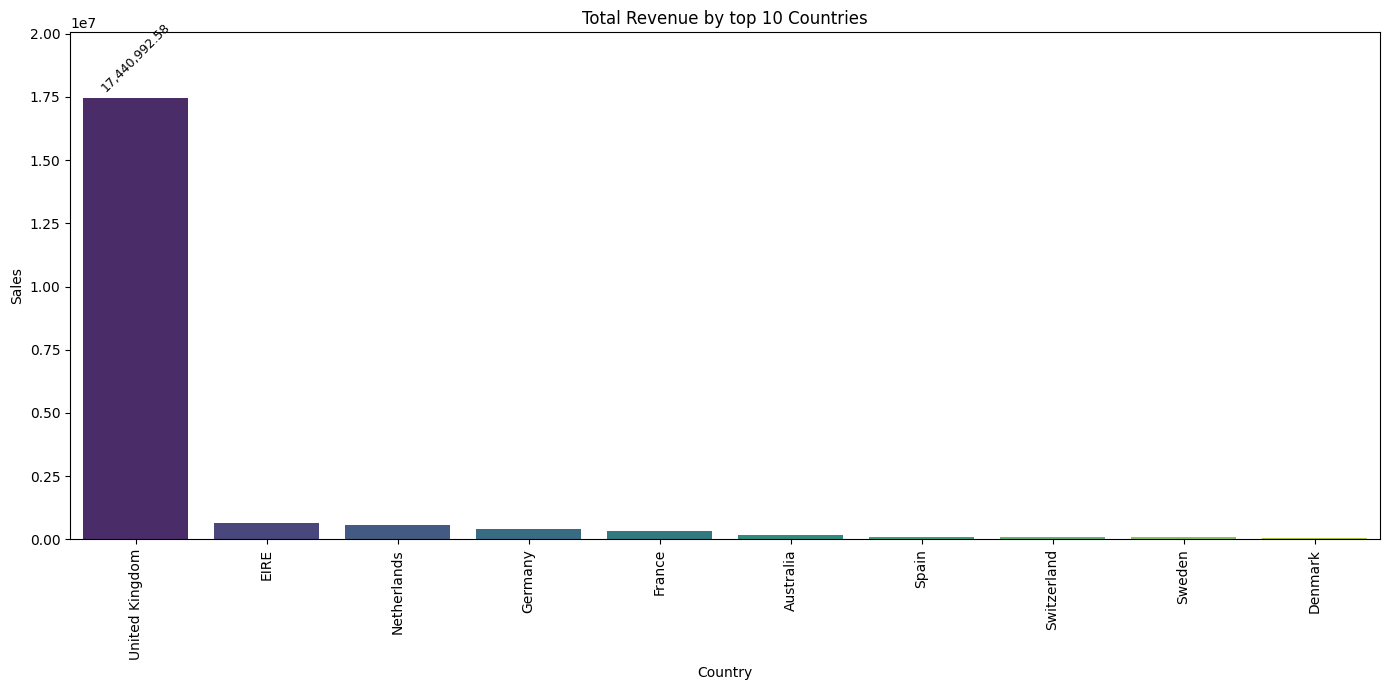

In [36]:
# 1. Create Revenue column
df_all = df_all.withColumn("Revenue", F.col("Quantity") * F.col("Price"))

# 2. Group by Country and sum the Revenue
country_revenue = df_all.groupBy("Country") \
                        .agg(F.sum("Revenue").alias("TotalRevenue")) \
                        .orderBy(F.desc("TotalRevenue")) \
                        .limit(10) \
                        .toPandas()

# 3. Plot the data
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=country_revenue.head(20), x="Country", y="TotalRevenue", palette="viridis")

# EDIT: Add exact values on top of bars
# We use comma formatting for large numbers to keep it readable
ax.bar_label(ax.containers[0], fmt='{:,.2f}', padding=3, rotation=45, fontsize=9)

plt.title("Total Revenue by top 10 Countries")
plt.ylabel("Sales")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.ylim(0, country_revenue['TotalRevenue'].max() * 1.15) # Add space for labels
plt.tight_layout()
plt.show()

## (7) Time-Series EDA

In [37]:
df_time = df_all.withColumn("Year", F.year("InvoiceDate")) \
                .withColumn("Month", F.month("InvoiceDate")) \
                .withColumn("Quarter", F.quarter("InvoiceDate"))

### a) Yearly sales trend

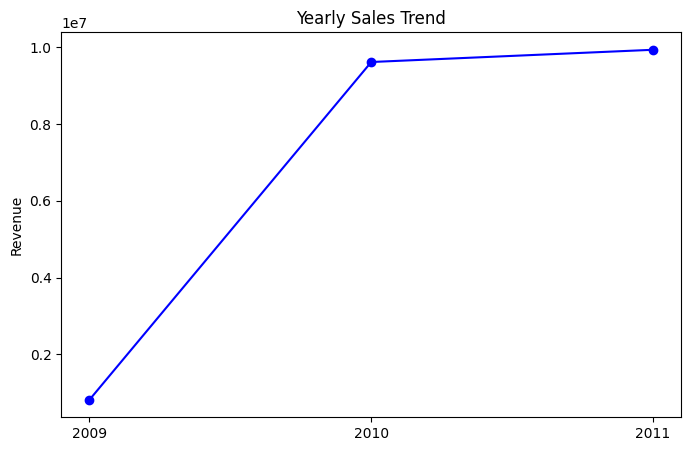

In [38]:
yearly_sales = df_time.groupBy("Year").agg(F.sum("Revenue").alias("Sales")).orderBy("Year").toPandas()
plt.figure(figsize=(8, 5))
plt.plot(yearly_sales['Year'].astype(str), yearly_sales['Sales'], marker='o', color='b')
plt.title("Yearly Sales Trend")
plt.ylabel("Revenue")
plt.show()

In [39]:
df_all = df_all.withColumn("Revenue", F.col("Quantity") * F.col("Price"))
df_time = df_all.withColumn("Year", F.year("InvoiceDate")) \
                .withColumn("Month", F.month("InvoiceDate")) \
                .withColumn("Quarter", F.quarter("InvoiceDate"))

### b) Montly sales trend for year 2010

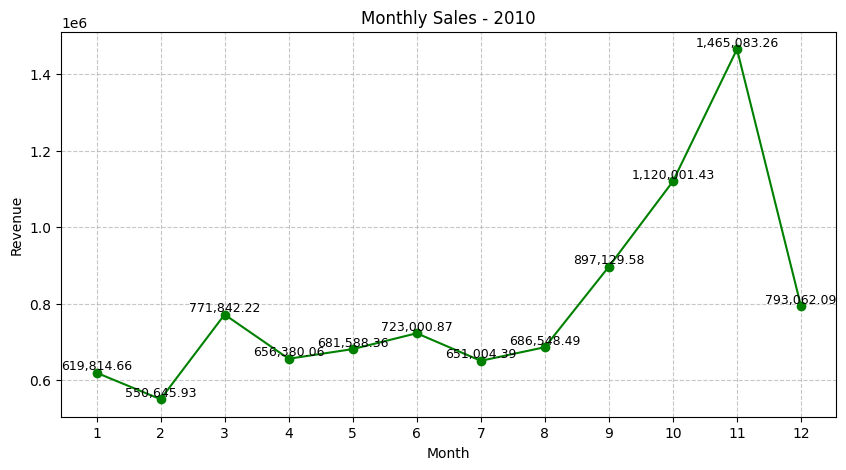

In [40]:
data_2010_m = df_time.filter(F.col("Year") == 2010).groupBy("Month").agg(F.sum("Revenue").alias("Sales")).orderBy("Month").toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(data_2010_m['Month'], data_2010_m['Sales'], marker='o', linestyle='-', color='green')

# Add Labels
for x, y in zip(data_2010_m['Month'], data_2010_m['Sales']):
    plt.text(x, y, f'{y:,.2f}', ha='center', va='bottom', fontsize=9)

plt.title("Monthly Sales - 2010")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### c) Quarterly sales trend for year 2010

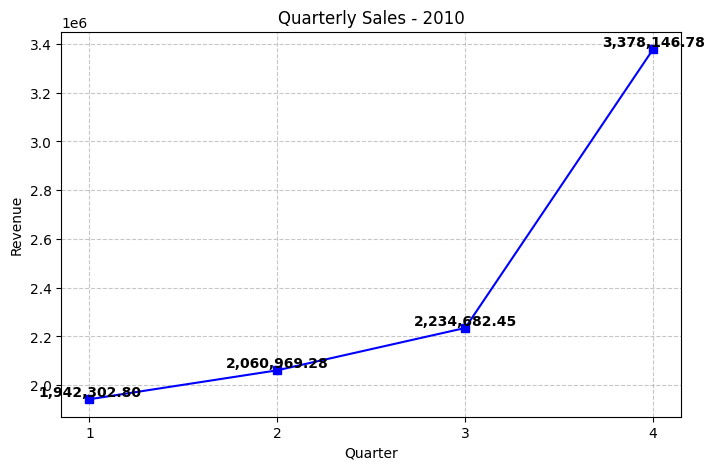

In [41]:
data_2010_q = df_time.filter(F.col("Year") == 2010).groupBy("Quarter").agg(F.sum("Revenue").alias("Sales")).orderBy("Quarter").toPandas()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(data_2010_q['Quarter'], data_2010_q['Sales'], marker='s', linestyle='-', color='blue')

# Add Labels
for x, y in zip(data_2010_q['Quarter'], data_2010_q['Sales']):
    plt.text(x, y, f'{y:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Quarterly Sales - 2010")
plt.xticks([1, 2, 3, 4]) # Strictly 1, 2, 3, 4
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### d) Montly sales trend for year 2011

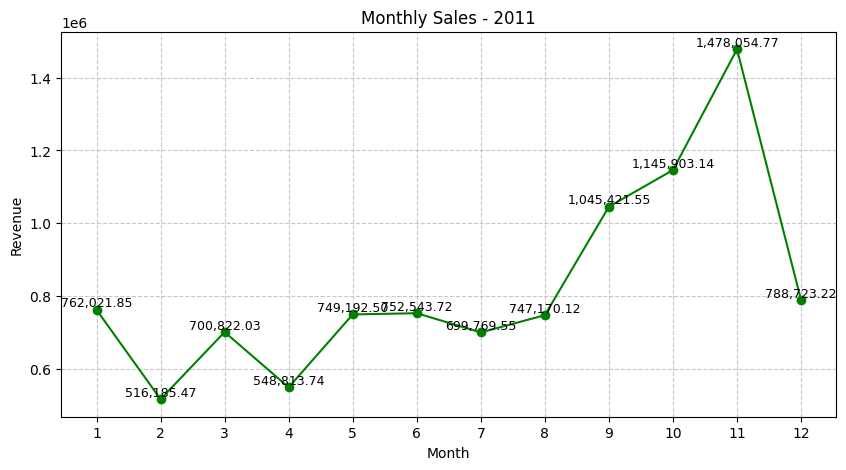

In [42]:
# Data Prep
data_2011_m = df_time.filter(F.col("Year") == 2011).groupBy("Month").agg(F.sum("Revenue").alias("Sales")).orderBy("Month").toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(data_2011_m['Month'], data_2011_m['Sales'], marker='o', linestyle='-', color='green')

# Add Labels
for x, y in zip(data_2011_m['Month'], data_2011_m['Sales']):
    plt.text(x, y, f'{y:,.2f}', ha='center', va='bottom', fontsize=9)

plt.title("Monthly Sales - 2011")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### e) Quarterly sales trend for year 2011

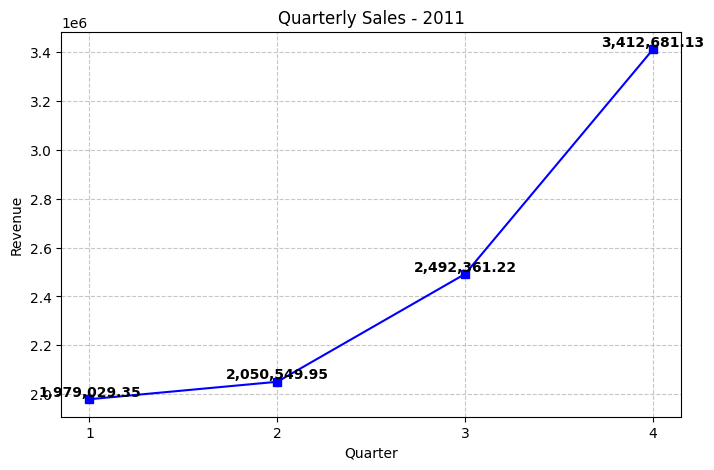

In [43]:
# Data Prep
data_2011_q = df_time.filter(F.col("Year") == 2011).groupBy("Quarter").agg(F.sum("Revenue").alias("Sales")).orderBy("Quarter").toPandas()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(data_2011_q['Quarter'], data_2011_q['Sales'], marker='s', linestyle='-', color='blue')

# Add Labels
for x, y in zip(data_2011_q['Quarter'], data_2011_q['Sales']):
    plt.text(x, y, f'{y:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Quarterly Sales - 2011")
plt.xticks([1, 2, 3, 4]) # Strictly 1, 2, 3, 4
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## (8) Customer EDA

### a) Top 10 customers according to spending

/tmp/ipykernel_18598/3714026416.py:6: FutureWarning:                            

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=top_cust, x="Customer ID", y="TotalSpent", palette="coolwarm")


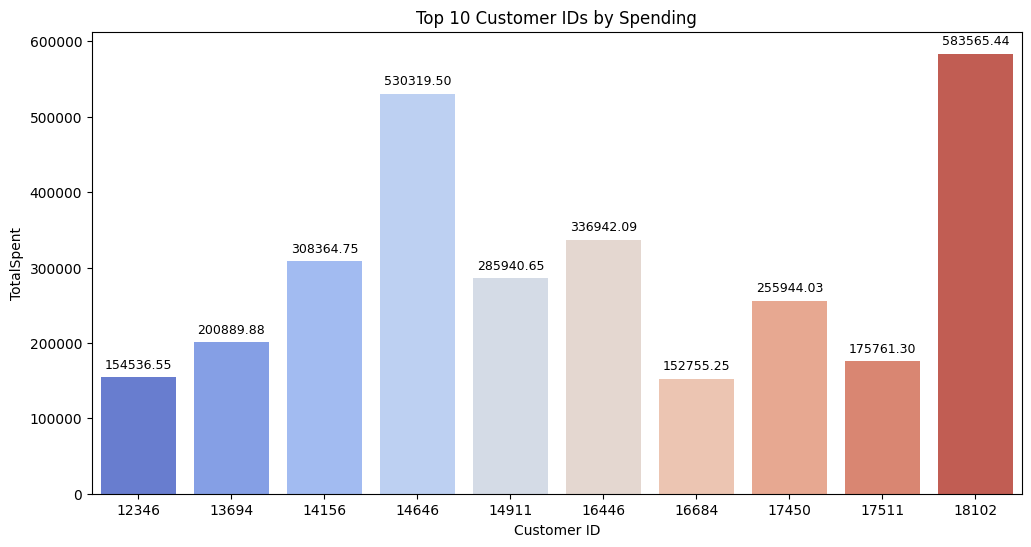

In [44]:
top_cust = df_customer_id.withColumn("Revenue", F.col("Quantity") * F.col("Price")) \
                         .groupBy("Customer ID").agg(F.sum("Revenue").alias("TotalSpent")) \
                         .orderBy(F.desc("TotalSpent")).limit(10).toPandas()

plt.figure(figsize=(12, 6))
ax4 = sns.barplot(data=top_cust, x="Customer ID", y="TotalSpent", palette="coolwarm")
add_labels(ax4)
plt.title("Top 10 Customer IDs by Spending")
plt.show()

### b) top 5 visiting customers according to number of invoices

/tmp/ipykernel_18598/1024016095.py:13: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_5_frequent,


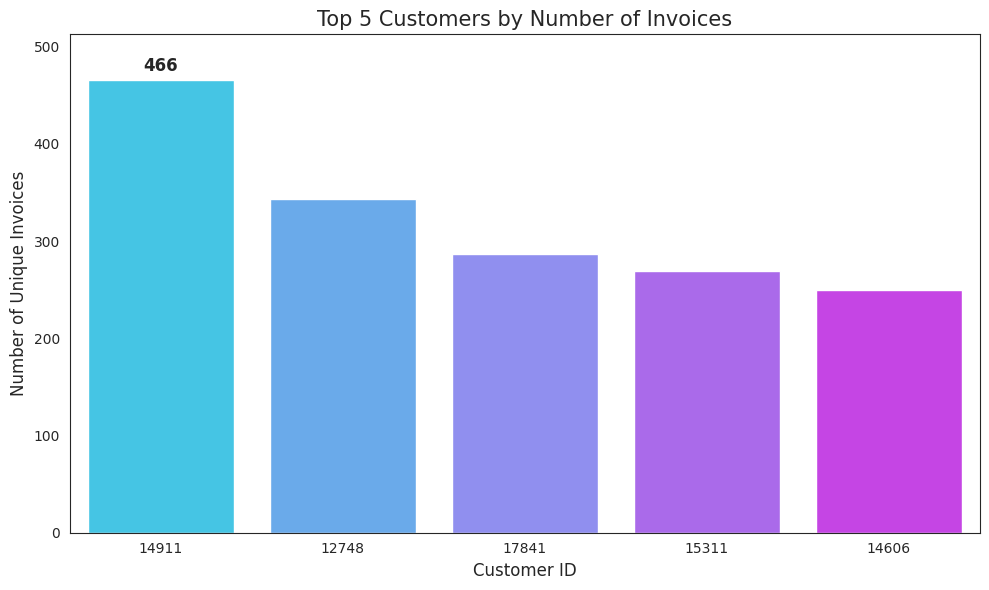

In [45]:
# 1. Group by Customer ID and count UNIQUE invoices
top_5_frequent = df_customer_id.groupBy("Customer ID") \
                               .agg(F.countDistinct("Invoice").alias("InvoiceCount")) \
                               .orderBy(F.desc("InvoiceCount")) \
                               .limit(5) \
                               .toPandas()

# 2. Create the Visual
plt.figure(figsize=(10, 6))
sns.set_style("white") # Clean background

# Note: Converting Customer ID to string so the x-axis doesn't treat them as continuous numbers
ax = sns.barplot(data=top_5_frequent,
                 x=top_5_frequent["Customer ID"].astype(str),
                 y="InvoiceCount",
                 palette="cool")

# 3. Add the exact values on top of the bars
ax.bar_label(ax.containers[0], padding=3, fontsize=12, fontweight='bold')

# Formatting
plt.title("Top 5 Customers by Number of Invoices", fontsize=15)
plt.xlabel("Customer ID", fontsize=12)
plt.ylabel("Number of Unique Invoices", fontsize=12)
plt.ylim(0, top_5_frequent["InvoiceCount"].max() * 1.1) # Add space for labels

plt.tight_layout()
plt.show()

In [46]:
spark.stop()